In [2]:
!pip install scikit-learn==1.4.2 scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [3]:
!pip install scikeras -q

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from sklearn.model_selection import RandomizedSearchCV

from scikeras.wrappers import KerasClassifier

In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


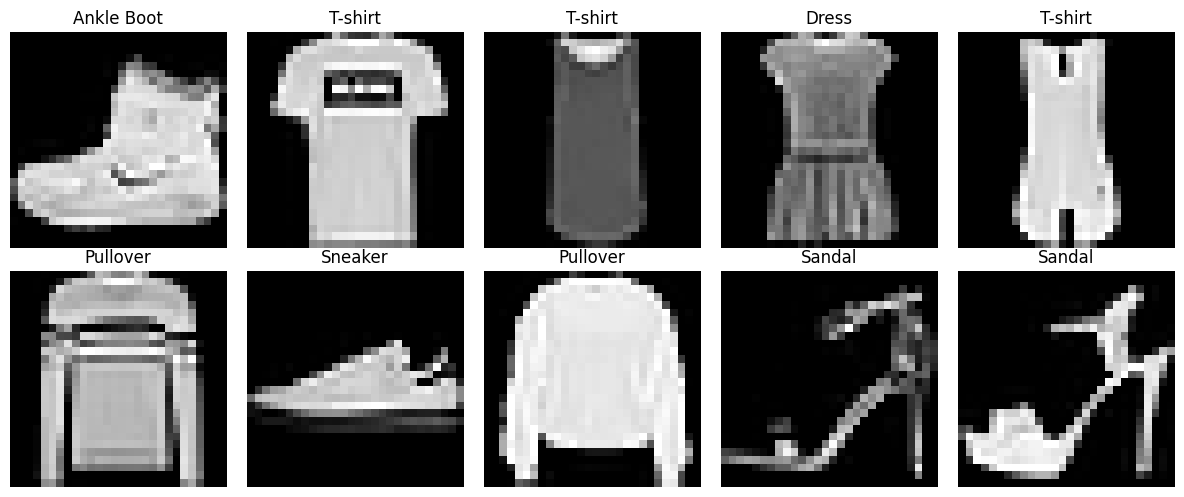

In [6]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle Boot'
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

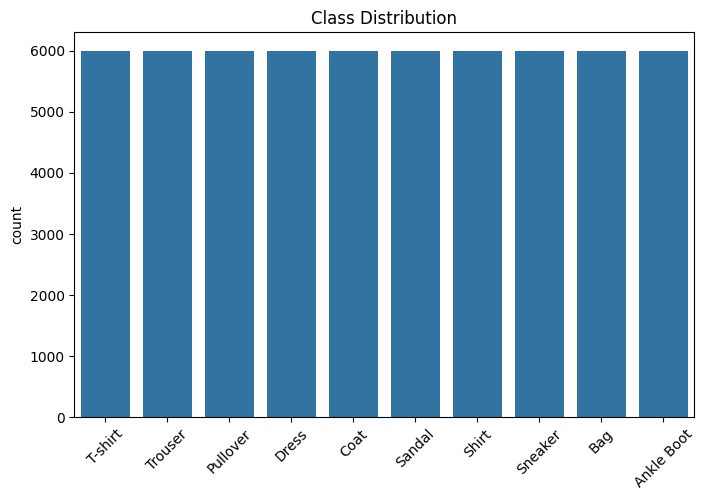

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train)

plt.xticks(range(10), class_names, rotation=45)

plt.title("Class Distribution")

plt.show()

In [8]:
# --- TASK 2: Data Preprocessing ---
print("--- TASK 2: Data Preprocessing ---")
print("Original X_train shape:", X_train.shape)

# Flatten images and normalize pixel values to [0,1]
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Flattened & Normalized X_train shape:", X_train_flat.shape)
print("One-hot y_train shape:", y_train_cat.shape)

--- TASK 2: Data Preprocessing ---
Original X_train shape: (60000, 28, 28)
Flattened & Normalized X_train shape: (60000, 784)
One-hot y_train shape: (60000, 10)


In [9]:
# --- TASK 3: Model Construction (Baseline) ---
print("\n--- TASK 3: Model Construction ---")
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()


--- TASK 3: Model Construction ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- TASK 4: Model Training (Baseline) ---
print("\n--- TASK 4: Model Training ---")
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Record training time
start_time_baseline = time.time()
baseline_history = baseline_model.fit(
    X_train_flat, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2, # Using 20% for validation to plot curves
    verbose=1
)
time_baseline = time.time() - start_time_baseline


--- TASK 4: Model Training ---
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8161 - loss: 0.5171 - val_accuracy: 0.8507 - val_loss: 0.4228
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8621 - loss: 0.3792 - val_accuracy: 0.8648 - val_loss: 0.3719
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8769 - loss: 0.3388 - val_accuracy: 0.8679 - val_loss: 0.3630
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8834 - loss: 0.3186 - val_accuracy: 0.8748 - val_loss: 0.3467
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8880 - loss: 0.2979 - val_accuracy: 0.8746 - val_loss: 0.3497
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8951 - loss: 0.2832 - val_accuracy: 0.8803 - val_loss: 0.3319
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8989 - loss: 0.2697 - val_accuracy: 0.8783 - val_loss: 0.3347
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - ac

In [11]:
# --- TASK 5: Model Evaluation (Baseline) ---
print("\n--- TASK 5: Model Evaluation (Baseline) ---")
baseline_preds = baseline_model.predict(X_test_flat)
baseline_pred_classes = np.argmax(baseline_preds, axis=1)

baseline_acc = accuracy_score(y_test, baseline_pred_classes)
baseline_prec = precision_score(y_test, baseline_pred_classes, average='weighted')
baseline_rec = recall_score(y_test, baseline_pred_classes, average='weighted')
baseline_f1 = f1_score(y_test, baseline_pred_classes, average='weighted')

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall: {baseline_rec:.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}")
print("\nClassification Report (Baseline):\n", classification_report(y_test, baseline_pred_classes, target_names=class_names))


--- TASK 5: Model Evaluation (Baseline) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Accuracy: 0.8837
Baseline Precision: 0.8857
Baseline Recall: 0.8837
Baseline F1-Score: 0.8836

Classification Report (Baseline):
               precision    recall  f1-score   support

     T-shirt       0.82      0.84      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.85      0.72      0.78      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.75      0.87      0.80      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.70      0.70      0.70      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [12]:
# --- HYPERPARAMETER OPTIMIZATION ---
print("\n--- Hyperparameter Optimization ---")

# Define a function to create the model for SciKeras
def create_model(hidden_layers=1, hidden_neurons=64, learning_rate=0.001, optimizer='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))

    # Add hidden layers dynamically
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Configure optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_cv = KerasClassifier(
    model=create_model,
    hidden_layers=1, hidden_neurons=64, learning_rate=0.001, optimizer='adam', activation='relu', dropout_rate=0.0,
    epochs=10, batch_size=32, verbose=0
)


param_grid = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_cv,
    param_distributions=param_grid,
    n_iter=5, # 5 iterations
    cv=5,     # 3-fold CV
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("Starting Randomized Search... (This may take several minutes)")
random_search_result = random_search.fit(X_train_flat, y_train_cat)

print(f"Best CV Accuracy: {random_search_result.best_score_:.4f}")
print(f"Best Parameters: {random_search_result.best_params_}")

best_params = random_search_result.best_params_


--- Hyperparameter Optimization ---
Starting Randomized Search... (This may take several minutes)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV Accuracy: 0.8852
Best Parameters: {'optimizer': 'adam', 'learning_rate': 0.001, 'hidden_neurons': 64, 'hidden_layers': 2, 'epochs': 30, 'dropout_rate': 0.2, 'batch_size': 128, 'activation': 'sigmoid'}



--- Retraining Best Model ---
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5865 - loss: 1.2118 - val_accuracy: 0.7725 - val_loss: 0.6780
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7757 - loss: 0.6480 - val_accuracy: 0.8242 - val_loss: 0.5040
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8138 - loss: 0.5356 - val_accuracy: 0.8378 - val_loss: 0.4512
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8283 - loss: 0.4910 - val_accuracy: 0.8459 - val_loss: 0.4226
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8364 - loss: 0.4620 - val_accuracy: 0.8517 - val_loss: 0.4045
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8443 - loss: 0.4412 - val_accuracy: 0.8550 - val_loss: 0.3933
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8474 - loss: 0.4280 - val_accuracy: 0.8583 - val_loss: 0.3873
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8501 - 

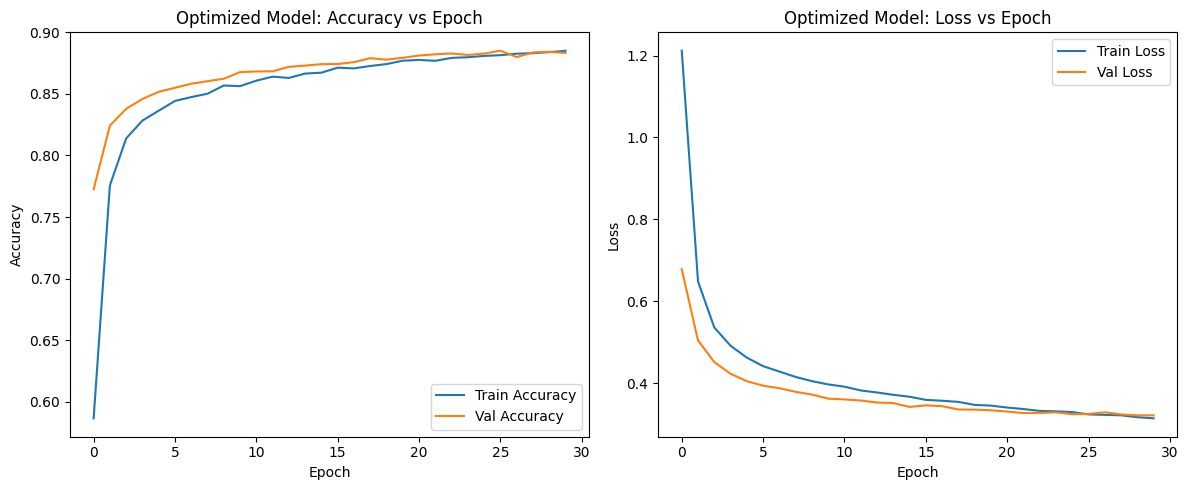

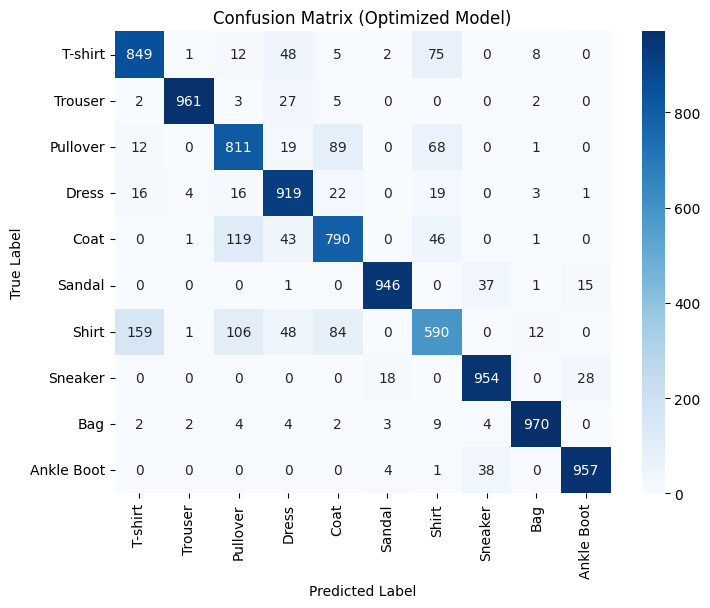

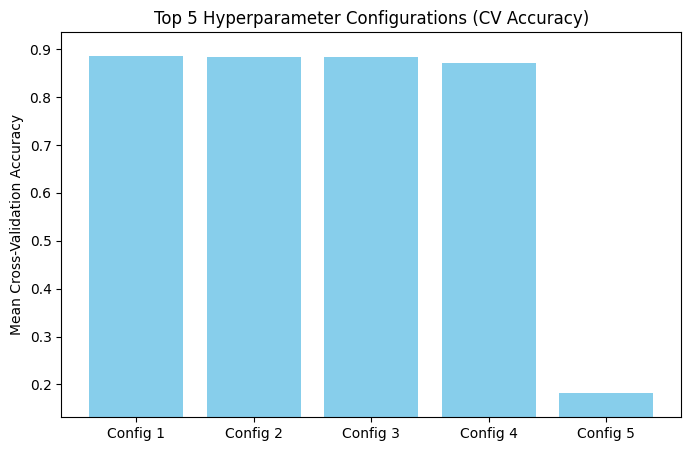

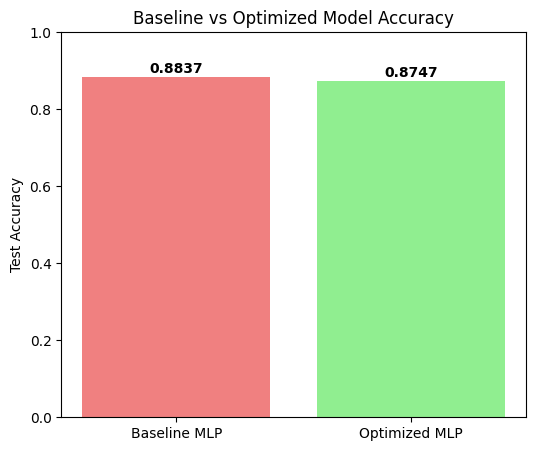

In [13]:
# --- RETRAIN WITH BEST HYPERPARAMETERS ---
print("\n--- Retraining Best Model ---")
best_model = create_model(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer=best_params['optimizer'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate']
)

start_time_opt = time.time()
opt_history = best_model.fit(
    X_train_flat, y_train_cat,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)
time_opt = time.time() - start_time_opt

# Evaluate optimized model
opt_preds = best_model.predict(X_test_flat)
opt_pred_classes = np.argmax(opt_preds, axis=1)

opt_acc = accuracy_score(y_test, opt_pred_classes)
opt_prec = precision_score(y_test, opt_pred_classes, average='weighted')
opt_rec = recall_score(y_test, opt_pred_classes, average='weighted')
opt_f1 = f1_score(y_test, opt_pred_classes, average='weighted')

print(f"\nOptimized Accuracy: {opt_acc:.4f}")

# --- MANDATORY PLOTS ---
print("\n--- Generating Mandatory Plots ---")

# 3 & 4. Training & Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(opt_history.history['accuracy'], label='Train Accuracy')
plt.plot(opt_history.history['val_accuracy'], label='Val Accuracy')
plt.title("Optimized Model: Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 5 & 6. Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(opt_history.history['loss'], label='Train Loss')
plt.plot(opt_history.history['val_loss'], label='Val Loss')
plt.title("Optimized Model: Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Confusion Matrix (Optimized Model)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, opt_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Optimized Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 8. Hyperparameter Search Results
results_df = pd.DataFrame(random_search.cv_results_)
top_5_idx = results_df['mean_test_score'].nlargest(5).index
top_5_scores = results_df.loc[top_5_idx, 'mean_test_score']

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(top_5_scores) + 1), top_5_scores, color='skyblue')
plt.xticks(range(1, len(top_5_scores) + 1), [f"Config {i}" for i in range(1, len(top_5_scores) + 1)])
plt.title("Top 5 Hyperparameter Configurations (CV Accuracy)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.ylim(min(top_5_scores)-0.05, max(top_5_scores)+0.05)
plt.show()

# 9. Best Model Accuracy Comparison
plt.figure(figsize=(6, 5))
models = ['Baseline MLP', 'Optimized MLP']
accuracies = [baseline_acc, opt_acc]
plt.bar(models, accuracies, color=['lightcoral', 'lightgreen'])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.title("Baseline vs Optimized Model Accuracy")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

In [14]:
print(f"Optimized Precision: {opt_prec:.4f}")
print(f"Optimized Recall: {opt_rec:.4f}")
print(f"Optimized F1-Score: {opt_f1:.4f}")

Optimized Precision: 0.8739
Optimized Recall: 0.8747
Optimized F1-Score: 0.8731
